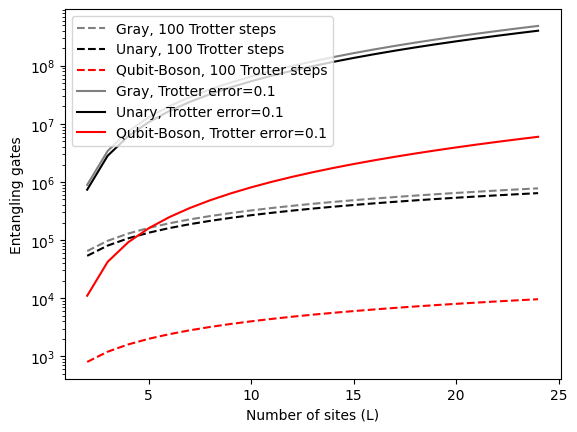

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Sawaya gate counts for displacements in Gray
# -------------------------
data = np.array([
[2.0100502512562812,-0.472813239],
[3.0552763819095476,2.8368794326241136],
[3.9798994974874375,3.7825059101654848],
[4.984924623115578,17.02127659574468],
[6.070351759,17.02127659574468],
[7.035175879396985,17.96690307328605],
[8.040201005025125,17.494089834515368],
[9.045226130653266,56.26477541371158],
[10.010050251256281,57.21040189125296],
[11.055276381909547,57.68321513002364],
[12.060301507537687,56.73758865248227],
[13.105527638190955,56.73758865248227],
[14.110552763819095,57.21040189125296],
[14.99497487437186,56.26477541371158],
[16.040201005025125,59.10165485],
[16.964824120603016,151.77304964539007],
[18.09045226130653,151.77304964539007],
[19.095477386934675,152.24586288416077],
[20.020100502512562,150.8274231678487],
[20.944723618090453,150.8274231678487],
[22.110552763819094,151.77304964539007],
[23.035175879396984,152.24586288416077],
[23.91959798994975,152.24586288416077],
[25.00502512562814,151.77304964539007],
[26.01005025125628,152.71867612293144],
[27.015075376884422,151.30023640661938],
[27.979899497487438,152.24586288416077],
[29.025125628140703,151.30023640661938],
[30.030150753768844,152.24586288416077],
[30.91457286432161,152.24586288416077],
[32.08040201005025,151.77304964539007]
])

x = data[:,0]
y = data[:,1]

# -------------------------
# Sawaya gate counts for displacements in unary
# -------------------------
data2 = np.array([
[2.0100502512562812,3.3096926713947994],
[3.0954773869346734,8.037825059101655],
[3.899497487437186,11.82033096926714],
[4.984924623115578,17.02127659574468],
[5.989949748743719,19.858156028368796],
[6.954773869346734,24.113475177304966],
[8,28.368794326241137],
[9.045226130653266,32.15130023640662],
[10.050251256281406,35.93380615],
[11.015075376884422,40.189125295508276],
[12.14070351758794,43.498817966903076],
[12.944723618090453,48.22695035460993],
[14.030150753768844,50.59101654846336],
[14.954773869346734,57.68321513002364],
[16,57.68321513002364],
[17.04522613065327,64.30260047281324],
[18.01005025125628,67.61229314420804],
[19.015075376884422,71.39479905437352],
[19.979899497487438,76.12293144208039],
[21.025125628140703,79.43262411347519],
[22.030150753768844,84.16075650118204],
[23.035175879396984,87.94326241134752],
[24,91.25295508274232],
[24.884422110552762,95.50827423167848],
[26.13065326633166,99.29078014184398],
[27.095477386934675,104.01891252955083],
[27.979899497487438,107.80141843971631],
[28.90452261306533,111.5839243498818],
[29.949748743718594,116.78486997635935],
[31.07537688442211,120.56737588652483],
[31.959798994974875,123.87706855791963]
])

# -------------------------
# Sawaya gate counts for displacements in Standard Binary (I found)
# -------------------------

x2 = data2[:,0]
y2 = data2[:,1]

# -------------------------
# Parameters
# -------------------------
N=np.arange(2, 25) #number of sites also called L
N_max=32 # cutoff
g=4
T=2
epsilon=0.1
cnot_D_gray=152
cnot_D_unary=124
# -------------------------
# Functions
# -------------------------

def alpha(N, N_max, J, g, delta_eps, hbar, omega_g):
    term1 = (N - 1)/2 * (abs(J)**2)
    term2 = (2*N - 3) * abs(J*g) * np.sqrt(N_max)
    term3 = (N*(N - 2)/4) * (3*abs(J*delta_eps))
    term4 = N * abs(hbar*omega_g) * np.sqrt(N_max)
    return term1 + term2 + term3 + term4

def trotter_steps(N, N_max=N_max, J=1, g=g, delta_eps=1, hbar=1, omega_g=1, T=T, epsilon=epsilon):
    return alpha(N, N_max, J, g, delta_eps, hbar, omega_g) * (T**2 / epsilon)

# NEGLECTS THE iSWAP GATE (because it is +1 for every two sites and so negligible and annoying because here we can just to number of sites times this).
def qubit_Hamiltonian_gate_count(N, cnot_D, N_max=N_max):
    return N*((2*cnot_D)+(4*np.log2(N_max)))  #2 displacements, 4 CP

def qubitboson_Hamiltonian_gate_count(N, N_max=N_max):
    return N*((2)+(2)) #2 displacements, 2 CP

# -------------------------
# Plot
# -------------------------
plt.figure()

plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray) * 100, label="Gray, 100 Trotter steps", ls="--", color="gray")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary) *  100, label="Unary, 100 Trotter steps", ls="--", color="k")
plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  100, label="Qubit-Boson, 100 Trotter steps", ls="--", color="red")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray) * trotter_steps(N), label="Gray, Trotter error=0.1", color="gray")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary) *  trotter_steps(N), label="Unary, Trotter error=0.1", color="k")
plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  trotter_steps(N), label="Qubit-Boson, Trotter error=0.1", color="red")

plt.yscale("log")

plt.xlabel("Number of sites (L)")
plt.ylabel("Entangling gates")

# plt.title("Parameters=1 except N_max=32, g=4, T=4.5")

plt.legend(loc="upper left")

plt.show()

In [2]:
# Holly: Webplotdigitizer

# -------------------------
# Sawaya gate counts for displacements in Gray
# -------------------------

sawaya_gray = np.array([
    [1.982905982905983, 0],
    [3.008547008547009, 4.01606425702812],
    [3.999999999999999, 3.614457831325325],
    [4.991452991452991, 18.07228915662651],
    [6.017094017094017, 18.07228915662651],
    [7.008547008547008, 18.07228915662651],
    [8.0, 17.670682730923716],
    [8.99145299145299, 57.42971887550203],
    [10.017094017094017, 57.42971887550203],
    [11.008547008547007, 57.02811244979921],
    [12.0, 57.42971887550203],
    [12.99145299145299, 57.42971887550203],
    [14.017094017094015, 57.02811244979921],
    [15.008547008547007, 57.02811244979921],
    [15.999999999999998, 57.42971887550203],
    [16.991452991452988, 152.20883534136544],
    [18.017094017094017, 152.20883534136544],
    [19.008547008547005, 152.20883534136544],
    [20.0, 152.20883534136544],
    [20.991452991452988, 152.20883534136544],
    [21.982905982905983, 152.20883534136544],
    [23.008547008547005, 151.80722891566268],
    [24.034188034188034, 151.80722891566268],
    [24.991452991452988, 152.20883534136544],
    [25.982905982905983, 151.80722891566268],
    [27.008547008547005, 152.20883534136544],
    [28.0, 152.20883534136544],
    [28.991452991452988, 151.80722891566268],
    [30.01709401709401, 152.20883534136544],
    [31.008547008547005, 152.20883534136544],
    [31.965811965811966, 152.20883534136544],
])

# -------------------------
# Sawaya gate counts for displacements in Standard Binary
# -------------------------

sawaya_sb = np.array([
    [1.982905982905983, -0.4016064257027665],
    [2.9743589743589745, 5.622489959839385],
    [3.965811965811966, 6.02409638554218],
    [4.957264957264957, 22.89156626506025],
    [6.017094017094017, 22.89156626506025],
    [7.008547008547008, 22.89156626506025],
    [8.0, 22.489959839357454],
    [8.99145299145299, 63.85542168674698],
    [10.017094017094017, 63.453815261044184],
    [11.008547008547007, 63.453815261044184],
    [12.0, 63.453815261044184],
    [12.99145299145299, 63.453815261044184],
    [14.017094017094015, 63.453815261044184],
    [15.008547008547007, 63.453815261044184],
    [16.034188034188034, 63.453815261044184],
    [16.991452991452988, 158.63453815261045],
    [18.017094017094017, 158.63453815261045],
    [19.04273504273504, 158.63453815261045],
    [20.0, 158.63453815261045],
    [20.991452991452988, 158.63453815261045],
    [21.982905982905983, 158.23293172690762],
    [23.04273504273504, 158.23293172690762],
    [24.0, 158.23293172690762],
    [25.025641025641022, 158.63453815261045],
    [26.017094017094017, 158.63453815261045],
    [27.008547008547005, 158.63453815261045],
    [28.0, 158.23293172690762],
    [28.957264957264954, 158.63453815261045],
    [29.982905982905976, 158.23293172690762],
    [31.008547008547005, 158.63453815261045],
    [31.965811965811966, 158.63453815261045],
])

# -------------------------
# Sawaya gate counts for displacements in Unary
# -------------------------

sawaya_unary = np.array([
    [2.017094017094017, 3.614457831325325],
    [3.008547008547009, 8.433734939759034],
    [3.999999999999999, 11.646586345381564],
    [5.0256410256410255, 16.06425702811248],
    [6.051282051282051, 19.678714859437775],
    [7.008547008547008, 24.09638554216872],
    [8.034188034188034, 27.710843373493987],
    [8.99145299145299, 32.12851405622493],
    [10.017094017094017, 35.742971887550226],
    [11.008547008547007, 39.35742971887552],
    [12.0, 43.77510040160644],
    [12.99145299145299, 47.79116465863456],
    [14.017094017094015, 51.40562248995985],
    [15.008547008547007, 55.421686746987945],
    [15.999999999999998, 59.83935742971889],
    [16.991452991452988, 63.85542168674698],
    [18.05128205128205, 67.8714859437751],
    [19.008547008547005, 71.4859437751004],
    [20.0, 75.50200803212851],
    [20.991452991452988, 79.51807228915666],
    [22.017094017094017, 83.53413654618475],
    [23.008547008547005, 87.55020080321285],
    [24.0, 91.56626506024097],
    [24.991452991452988, 95.98393574297188],
    [25.982905982905983, 99.59839357429718],
    [27.008547008547005, 104.01606425702812],
    [28.0, 107.63052208835342],
    [28.991452991452988, 112.04819277108436],
    [29.982905982905976, 115.66265060240966],
    [31.008547008547005, 120.08032128514057],
    [31.999999999999993, 123.69477911646587],
])

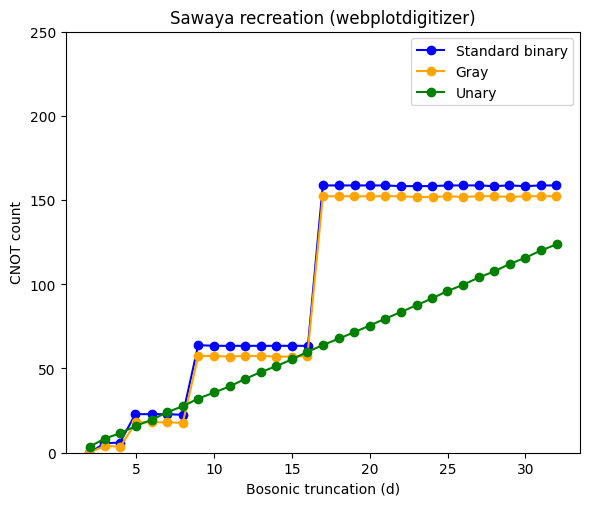

In [3]:
plt.figure(figsize=(6, 5))

plt.plot(
    sawaya_sb[:, 0],
    sawaya_sb[:, 1],
    color="blue",
    marker="o",
    label="Standard binary",
)

plt.plot(
    sawaya_gray[:, 0],
    sawaya_gray[:, 1],
    marker="o",
    color="orange",
    label="Gray",
)

plt.plot(
    sawaya_unary[:, 0],
    sawaya_unary[:, 1],
    marker="o",
    color="green",
    label="Unary",
)

plt.xlabel("Bosonic truncation (d)")
plt.ylabel("CNOT count")
plt.ylim(0, 250)
plt.legend()
plt.tight_layout()
plt.title("Sawaya recreation (webplotdigitizer)")
plt.show()

In [13]:
# Holly : Below contains the no. of sites vs entagling gates using the qiskit optimizer and PET parameters for:
# 1) Qiskit optimized circuit and 1 Trotter step
# 2) Qiskit optimized circuit and 10 Trotter steps

# Rewrote the functions for trotter error with small pre-factors

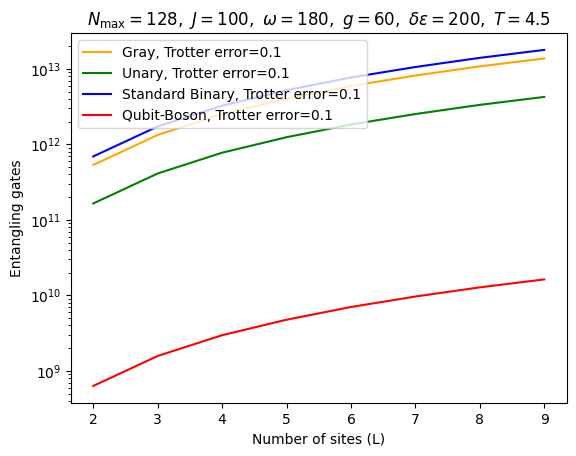

In [ ]:
# 1) Qiskit optimized circuit and 1 Trotter step

cnot_D_gray_holly=1674
cnot_D_sb_holly= 2175
cnot_D_unary_holly=508

N = np.arange(2, 10)

# Parameters:

N_max = 128
g = 60
T = 4.5
J = 100
omega = 180
epsilon = 0.1 # we set the Trotter error


def alpha(N, N_max, J, g, tilt, hbar, omega):
    term1 = 2 * np.floor(N / 2) * abs(J)**2
    term2 = (4 * (N - 1) * abs(J * g) * np.sqrt(N_max))
    floor_term = np.floor((N - 1) / 2)
    term3 = (abs(J * tilt) * (4 * floor_term**2 + 2 * floor_term + (N - 1)))
    term4 = (2 * N * abs(hbar * omega * g) * np.sqrt(N_max))
    return term1 + term2 + term3 + term4

def trotter_steps(N, N_max=N_max, J=J, g=g, delta_eps=1, hbar=1, omega=omega, T=T, epsilon=epsilon):
    return alpha(N, N_max, J, g, delta_eps, hbar, omega) * T**2 / (2 * epsilon) # The 2 is needed for the small parameters

# 

# Gates per trotter step (NEGLECTS THE iSWAP GATE (because it is +1 for every two sites and so negligible and annoying because here we can just to number of sites times this)).
def qubit_Hamiltonian_gate_count(N, cnot_D, N_max=N_max):
    return N*((2*cnot_D)+(4*np.log2(N_max)))  #2 displacements, 4 CP

def qubitboson_Hamiltonian_gate_count(N, N_max=N_max):
    return N*((2)+(2)) #2 displacements, 2 CP


# -------------------------
# Plot
# -------------------------
plt.figure()

# plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray) * 100, label="Gray, 100 Trotter steps", ls="--", color="gray")
# plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary) *  100, label="Unary, 100 Trotter steps", ls="--", color="k")
# plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  100, label="Qubit-Boson, 100 Trotter steps", ls="--", color="red")

# Gray
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray_holly) * trotter_steps(N), label="Gray, Trotter error=0.1", color="orange") # multiply each by the number of trotter steps
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary_holly) *  trotter_steps(N), label="Unary, Trotter error=0.1", color="green")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_sb_holly) *  trotter_steps(N), label="Standard Binary, Trotter error=0.1", color="blue")
plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  trotter_steps(N), label="Qubit-Boson, Trotter error=0.1", color="red")

plt.yscale("log")

plt.xlabel("Number of sites (L)")
plt.ylabel("Entangling gates")

# plt.title("Parameters=1 except N_max=32, g=4, T=4.5")

plt.legend(loc="upper left")
plt.title(
    r"$N_{\max}=128,\ J=100,\ \omega=180,\ g=60,\ "
    r"\delta\epsilon=200,\ T=4.5$"
)
plt.show()

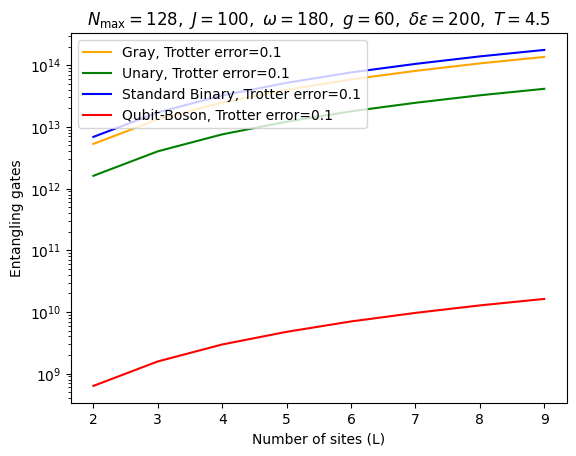

In [19]:
# 2) Qiskit optimized circuit and 10 Trotter steps

cnot_D_gray=16740
cnot_D_sb= 21741
cnot_D_unary=5080

# Parameters:

N_max = 128
g = 60
T = 4.5
J = 100
omega = 180
epsilon = 0.1 # we set the Trotter error

def alpha(N, N_max, J, g, tilt, hbar, omega):
    term1 = 2 * np.floor(N / 2) * abs(J)**2
    term2 = (4 * (N - 1) * abs(J * g) * np.sqrt(N_max))
    floor_term = np.floor((N - 1) / 2)
    term3 = (abs(J * tilt) * (4 * floor_term**2 + 2 * floor_term + (N - 1)))
    term4 = (2 * N * abs(hbar * omega * g) * np.sqrt(N_max))
    return term1 + term2 + term3 + term4

def trotter_steps(N, N_max=N_max, J=J, g=g, delta_eps=1, hbar=1, omega=omega, T=T, epsilon=epsilon):
    return alpha(N, N_max, J, g, delta_eps, hbar, omega) * T**2 / (2 * epsilon)  # The 2 is needed for the small parameters


# NEGLECTS THE iSWAP GATE (because it is +1 for every two sites and so negligible and annoying because here we can just to number of sites times this).
def qubit_Hamiltonian_gate_count(N, cnot_D, N_max=N_max):
    return N*((2*cnot_D)+(4*np.log2(N_max)))  #2 displacements, 4 CP

def qubitboson_Hamiltonian_gate_count(N, N_max=N_max):
    return N*((2)+(2)) #2 displacements, 2 CP


# -------------------------
# Plot
# -------------------------
plt.figure()

# plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray) * 100, label="Gray, 100 Trotter steps", ls="--", color="gray")
# plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary) *  100, label="Unary, 100 Trotter steps", ls="--", color="k")
# plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  100, label="Qubit-Boson, 100 Trotter steps", ls="--", color="red")

# Gray
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray) * trotter_steps(N), label="Gray, Trotter error=0.1", color="orange")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary) *  trotter_steps(N), label="Unary, Trotter error=0.1", color="green")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_sb) *  trotter_steps(N), label="Standard Binary, Trotter error=0.1", color="blue")
plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  trotter_steps(N), label="Qubit-Boson, Trotter error=0.1", color="red")

plt.yscale("log")

plt.xlabel("Number of sites (L)")
plt.ylabel("Entangling gates")

# plt.title("Parameters=1 except N_max=32, g=4, T=4.5")

plt.legend(loc="upper left")
plt.title(
    r"$N_{\max}=128,\ J=100,\ \omega=180,\ g=60,\ "
    r"\delta\epsilon=200,\ T=4.5$"
)
plt.show()

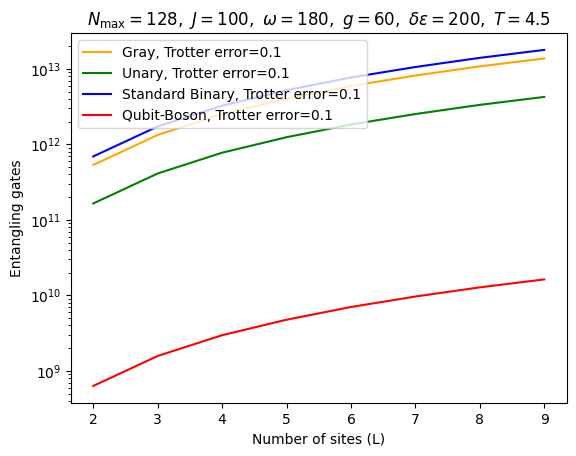

In [ ]:
# Holly: All-qubit 10 Trotter steps for displacement operator (N_max = 128, J = 100, w = 180, g = 60, tilit = 200, t = 4.5)

cnot_D_gray=16740
cnot_D_sb= 21741
cnot_D_unary=5080

# Parameters:

N_max = 128
g = 60
T = 4.5
J = 100
omega = 180
epsilon = 0.1 # we set the Trotter error

def alpha(N, N_max, J, g, tilt, hbar, omega):
    term1 = 2 * np.floor(N / 2) * abs(J)**2
    term2 = (4 * (N - 1) * abs(J * g) * np.sqrt(N_max))
    floor_term = np.floor((N - 1) / 2)
    term3 = (abs(J * tilt) * (4 * floor_term**2 + 2 * floor_term + (N - 1)))
    term4 = (2 * N * abs(hbar * omega * g) * np.sqrt(N_max))
    return term1 + term2 + term3 + term4

def trotter_steps(N, N_max=N_max, J=J, g=g, delta_eps=1, hbar=1, omega=omega, T=T, epsilon=epsilon):
    return alpha(N, N_max, J, g, delta_eps, hbar, omega) * (T**2 / (2 * epsilon)) # The 2 is needed for the small parameters


# NEGLECTS THE iSWAP GATE (because it is +1 for every two sites and so negligible and annoying because here we can just to number of sites times this).
def qubit_Hamiltonian_gate_count(N, cnot_D, N_max=N_max):
    return N*((2*cnot_D)+(4*np.log2(N_max)))  #2 displacements, 4 CP

def qubitboson_Hamiltonian_gate_count(N, N_max=N_max):
    return N*((2)+(2)) #2 displacements, 2 CP


# -------------------------
# Plot
# -------------------------
plt.figure()

# plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray) * 100, label="Gray, 100 Trotter steps", ls="--", color="gray")
# plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary) *  100, label="Unary, 100 Trotter steps", ls="--", color="k")
# plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  100, label="Qubit-Boson, 100 Trotter steps", ls="--", color="red")

# Gray
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_gray_holly) * trotter_steps(N), label="Gray, Trotter error=0.1", color="orange")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_unary_holly) *  trotter_steps(N), label="Unary, Trotter error=0.1", color="green")
plt.plot(N, qubit_Hamiltonian_gate_count(N,cnot_D=cnot_D_sb_holly) *  trotter_steps(N), label="Standard Binary, Trotter error=0.1", color="blue")
plt.plot(N, qubitboson_Hamiltonian_gate_count(N) *  trotter_steps(N), label="Qubit-Boson, Trotter error=0.1", color="red")

plt.yscale("log")

plt.xlabel("Number of sites (L)")
plt.ylabel("Entangling gates")

# plt.title("Parameters=1 except N_max=32, g=4, T=4.5")

plt.legend(loc="upper left")
plt.title(
    r"$N_{\max}=128,\ J=100,\ \omega=180,\ g=60,\ "
    r"\delta\epsilon=200,\ T=4.5$"
)
plt.show()